# Stochastischer Prozess

## Übungsblatt

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Aufgabe 1: Computerspiel

Bei einem Computerspiel gibt es drei Zustände: Level 1, Level 2 und Level 3. Eine Spielerin beginnt auf Level 1 und bewältigt die Übergänge von Level 1 nach Level 2 mit einer Wahrscheinlichkeit von 80 % und von 2 nach 3 mit einer Wahrscheinlichkeit von 60 %. Ein Level zurückfallen ist nicht möglich. Sie spielt so lange, bis sie Level 3 erreicht hat.

Der Ablauf (von Level zu Level) ist eine Markow-Kette. Sie kann durch ein "unendliches" Baumdiagramm oder ein Prozessdiagramm mit drei Zuständen beschrieben werden:

> ![Baumdiagramm & Prozessdiagramm eines Computerspiels](mc_computerspiel.png)
>
> Meyer, J. (o. J.). *Modellieren und Rechnen mit Matrizen* [Skript]. Mathe-Sport-Lehrer. Abgerufen 27. Januar 2026, von https://www.maspole.de/index.php/mathematikunterricht/jahrgang-13-g9-q2-phase/modellieren-mit-matrizen/download/88-modellieren-und-rechnen-mit-matrizensse/1036-13-modellieren-und-rechnen-mit-matrizen-skript

Schreibe eine Funktion `play_game(seed=None)`, die den Spielverlauf simuliert und die Anzahl der benötigten Versuche zurückgibt, bis die Spielerin das Level 3 erreicht und noch nicht gespielt hat. Der Parameter `seed` ist dabei der Seed für den Defaul Random Generator von NumPy und der Standardwert `None` bedeutet, dass der Seed "zufällig" gewählt wird.


In [2]:
p_12 = 0.8
p_23 = 0.6


def play_game(seed=None):
    rng = np.random.default_rng(seed)
    level = 1
    attempts = 0
    while level < 3:
        attempts += 1
        p = p_12 if level == 1 else p_23
        if rng.random() < p:
            level += 1
    return attempts

In [3]:
print(f"Die Spielerin erreichte Level 3 nach {play_game()} Versuchen.")

Die Spielerin erreichte Level 3 nach 4 Versuchen.


Alternative Implementation mit der Übergangsmatrix (engl. transition matrix):

In [4]:
levels = (1, 2, 3)
transition_matrix = (
    None,
    (1 - p_12, p_12, 0),
    (0, 1 - p_23, p_23),
    (0, 0, 1),
)


def play_game2(seed=None):
    rng = np.random.default_rng(seed)
    level = 1
    attempts = 0
    while level < 3:
        attempts += 1
        level = rng.choice(levels, p=transition_matrix[level])
    return attempts


print(f"Die Spielerin erreichte Level 3 nach {play_game2()} Versuchen.")

Die Spielerin erreichte Level 3 nach 3 Versuchen.


#### b) Mittlere Spieldauer mit Monte-Carlo-Simulation schätzen

Simuliere das Spiel `play_game()` nun 10'000 Mal (Monte-Carlo-Simulation) mit unterschiedlichen Seeds (oder immer `seed=None`) und sammle die benötigten Versuche in einem Array.

Berechne den Mittelwert und die Standardabweichung der benötigten Versuche.

In [5]:
n = 10_000
attemps = np.array([play_game() for _ in range(n)])
attemps.mean(), attemps.std()

(np.float64(2.8817), np.float64(1.1399583808192297))

#### c) Relative Häufigkeiten der Anzahl Versuche

Bereche die relative Häufigkeit, dass die Spielerin nach $n$ Versuchen Level 3 erreicht hat und stelle sie mit einem Bar-Plot dar. Verwende dazu die Resultate der 10'000 Simulationen aus Teil b).

Hierfür kannst du entweder Pandas [`pd.Series.values_counts`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.value_counts.html), [`Counter`](https://docs.python.org/3/library/collections.html#collections.Counter) oder [`np.bincount`](https://numpy.org/doc/stable/reference/generated/numpy.bincount.html) verwenden.

 Was fällt dir auf? Wenn du die y-Achse logarithmisch darstellst, siehst du, wie die Häufigkeit von der Anzahl Versuche abhängt. Was kannst du dazu sagen?

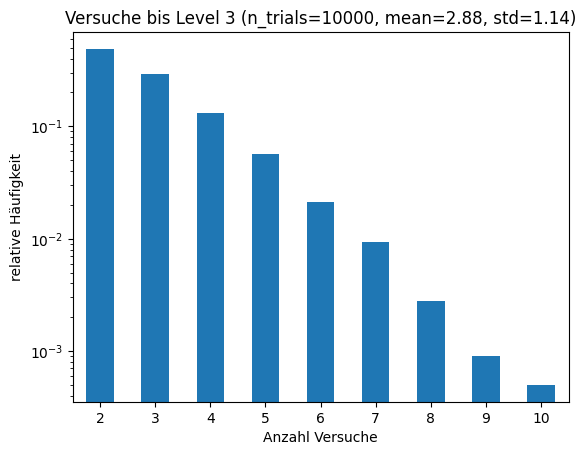

In [6]:
ax = (
    pd.Series(attemps)
    .value_counts(normalize=True)
    .sort_index()
    .plot(
        kind="bar",
        title=f"Versuche bis Level 3 (n_trials={n}, mean={attemps.mean():.2f}, std={attemps.std():.2f})",
        xlabel="Anzahl Versuche",
        ylabel="relative Häufigkeit",
        rot=0,
        logy=True,
    )
)

### Aufgabe 2: Random Walk in 1D


Der Random Walk (dt. "zufälliger Spaziergang") ist ein Konzept aus der Stochastik, das in vielen Bereichen der Physik, Mathematik und Informatik Anwendung findet. Er beschreibt eine mathematische Idee, bei der ein Teilchen auf einem Gitter oder in einem Raum eine zufällige Bewegung ausführt.

Ein Random Walk kann auf verschiedene Weise durchgeführt werden, aber im Allgemeinen besteht er aus einer Abfolge von Schritten, die zufällig in verschiedene Richtungen durchgeführt werden. Jeder Schritt kann eine feste Länge haben oder eine zufällige Länge zwischen einem bestimmten Minimum und Maximum.

Random Walks sind in vielen Bereichen nützlich, da sie helfen, das Verhalten von Partikeln oder Molekülen in einer Flüssigkeit oder Gas zu modellieren, das Wachstum von Zellen in einem Gewebe zu simulieren oder das Verhalten von Tieren bei der Futtersuche zu untersuchen. Sie können auch in der Finanzmathematik verwendet werden, um den Preis von Wertpapieren oder Optionen zu modellieren.

Ein wichtiger Aspekt des Random Walks ist die Wahrscheinlichkeitsverteilung der Schritte, die das Teilchen durchführt. Wenn die Schritte zufällig sind und die Wahrscheinlichkeitsverteilung der Schrittlängen symmetrisch ist, d.h. sie hat das gleiche Gewicht für positive und negative Werte, dann wird der Random Walk als "einfacher Random Walk" bezeichnet.

Eine weitere wichtige Eigenschaft von Random Walks ist die Tatsache, dass sie dazu neigen, sich auszubreiten oder zu diffundieren. Das bedeutet, dass sich das Teilchen im Durchschnitt mit der Wurzel aus der Anzahl der durchgeführten Schritte von seinem ursprünglichen Ausgangspunkt entfernt. Dies ist ein grundlegendes Prinzip der Diffusionsphysik und wird in vielen Anwendungen wie der Molekularbiologie, der Physik von Flüssigkeiten und Gasen sowie der Finanzmathematik verwendet.

Optionales Material:
- ["What is a Random Walk? | Infinite Series" - PBS Infinite Series](https://www.youtube.com/watch?v=stgYW6M5o4k&t=177s)
- ["Random walks in 2D and 3D are fundamentally different (Markov chains approach)" - Mathemaniac](https://www.youtube.com/watch?v=iH2kATv49rc&t=141s)
- ["Random Walk" - Wikipedia](https://de.wikipedia.org/wiki/Random_Walk)

#### a) Random Walk simulieren

Schreibe eine Funktion `random_walk_1d(n_steps, seed=None)`, die einen Random Walk mit `n` Schritten in 1D simuliert. Die Funktion soll einen NumPy Default Random Generator mit dem gegebenen Seed nutzen und die abgelaufenen Positionen $x_i$ in einem Array zurückgeben.

- Startposition: $x_0 = 0$.
- Iterationsvorschrift: $x_{n+1} = x_n + d_{n+1}$.
- Der Schritt $d_{n+1}$ wird zufällig aus der Menge $\{-1, 1\}$ gewählt. Das heisst, die Schrittlänge ist immer 1, die Richtung ist zufällig.

Verwende dazu die Funktion [`rng.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.choice.html).

Mit dem Seed `42` und 10 Schritten sollte die Ausgabe wie folgt aussehen: `[0, -1,  0,  1,  0, -1,  0, -1,  0, -1, -2]`

In [7]:
def random_walk_1d(n_steps, seed=None):
    rng = np.random.default_rng(seed)
    x = 0
    walk = [x]
    for _ in range(n_steps):
        x += rng.choice([-1, 1])
        walk.append(x)
    return np.array(walk)


random_walk_1d(10, 42)

array([ 0, -1,  0,  1,  0, -1,  0, -1,  0, -1, -2])

In [8]:
# Alternative Implementierung mit NumPy


def random_walk_1d(n_steps, seed=None):
    rng = np.random.default_rng(seed)
    steps = rng.choice([-1, 1], n_steps)
    steps = np.hstack([0, steps])
    return np.cumsum(steps)


random_walk_1d(10, 42)

array([ 0, -1,  0,  1,  0, -1,  0, -1,  0, -1, -2])

#### b) Darstellung des Random Walks

Simuliere einen `random_walk_1d()` mit 1000 Schritten und stelle den Verlauf dar.

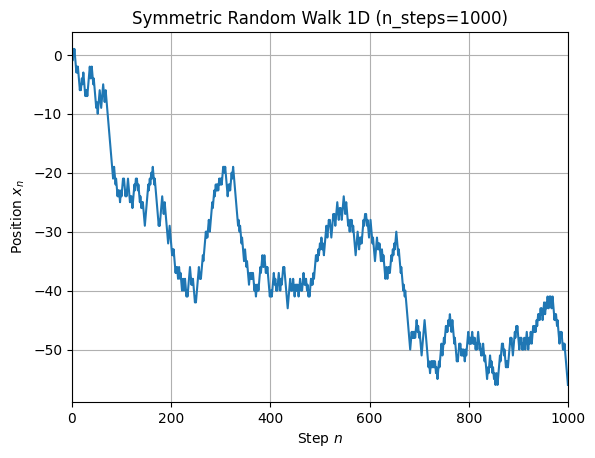

In [9]:
n_steps = 1000
walk = random_walk_1d(n_steps)

plt.plot(walk)
plt.xlabel("Step $n$")
plt.ylabel("Position $x_n$")
plt.title(f"Symmetric Random Walk 1D (n_steps={n_steps})")
plt.grid()
plt.xlim(0, n_steps)
plt.show()

#### c) Darstellen mehrerer Random Walks


Stelle 5 Random Walks mit je 1000 Schritten und unterschiedlichen Seeds in einem Plot dar. Verwende dazu die Funktion `random_walk_1d()` aus Aufgabe b).

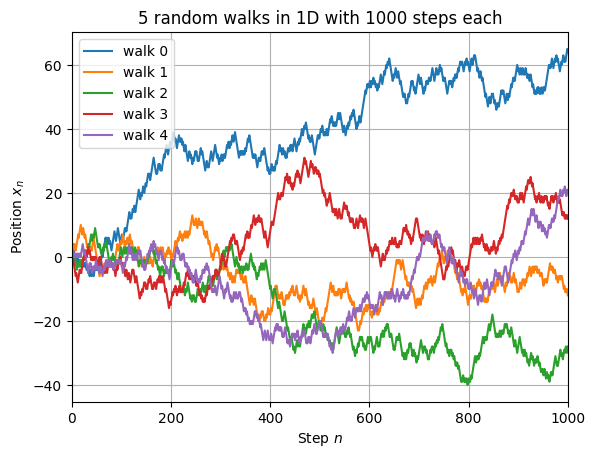

In [10]:
n_steps = 1000
n_walks = 5

for i in range(n_walks):
    walk = random_walk_1d(n_steps)
    plt.plot(walk, label=f"walk {i}")

plt.xlabel("Step $n$")
plt.ylabel("Position $x_n$")
plt.legend()
plt.title(f"{n_walks} random walks in 1D with {n_steps} steps each")
plt.grid()
plt.xlim(0, n_steps)
plt.show()

#### d) Varianz des Random Walks


Wie man in Aufgabe c) sehen kann, driften die Random Walks in 1D mit der Zeit (Anzahl Schritte) auseinander. [Man kann zeigen](https://de.wikipedia.org/wiki/Random_Walk#Eindimensionaler_Fall), dass die Varianz der Aufenthaltsverteilung der Walks mit der Anzahl Schritte linear ansteigt:

$$ \text{Var}(X_n) = n $$

Also ist die Standardabweichung nach $n$ Schritten:

$$ \sigma_n = \sqrt{\text{Var}(X_n)} = \sqrt{n} $$

Das Ziel ist nun, dieses theoretische Resultat mit einer Monte-Carlo-Simulation zu verifizieren.

- Erzeuge 500 Random Walks mit je 1000 Schritten und unterschiedlichen Seeds mithilfe von `random_walk_1d()`.
- Packe die resultierenden 500 Walks in ein Array zu einem 2D Array mit Shape (500, 1001). Das heisst jede Zeile ist ein Walk und die $i$-te Spalte entspricht den Positionen der Walks nach $i$ Schritten.
- Berechne die Standardabweichung mit [`np.std`](https://numpy.org/doc/stable/reference/generated/numpy.std.html) pro Spalte, also jeweils über alle Zeilen. (Nutze die Option `axis`.)
- Stelle die Standardabweichung als Funktion des Schritts dar und vergleiche diese mit der theoretischen Standardabweichung $\sigma_n = \sqrt{n}$.
- Stelle dazu auch noch den Mittelwert der Walks dar. Was fällt dir auf? Warum ist das so?

In [11]:
n_steps = 1000
n_walks = 500

walks = np.array([random_walk_1d(n_steps) for _ in range(n_walks)])
walks.shape

(500, 1001)

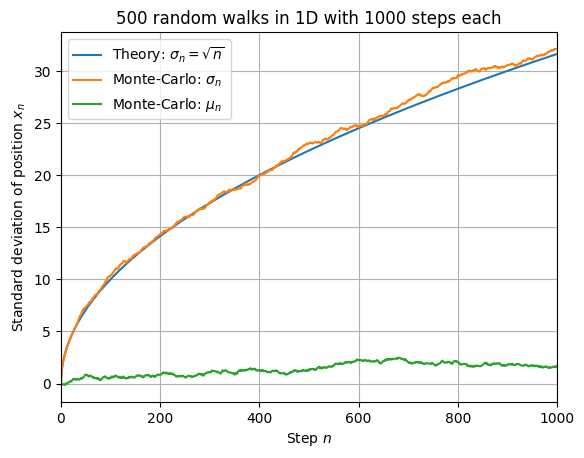

In [12]:
sigma_theory = np.sqrt(np.arange(n_steps))
sigma_walks = np.std(walks, axis=0)
mean_walks = np.mean(walks, axis=0)

plt.plot(sigma_theory, label=r"Theory: $\sigma_n = \sqrt{n}$")
plt.plot(sigma_walks, label=r"Monte-Carlo: $\sigma_n$")
plt.plot(mean_walks, label=r"Monte-Carlo: $\mu_n$")
plt.xlabel("Step $n$")
plt.ylabel("Standard deviation of position $x_n$")
plt.title(f"{n_walks} random walks in 1D with {n_steps} steps each")
plt.grid()
plt.legend()
plt.xlim(0, n_steps)
plt.show()

**Beobachtungen**:
- Die Standardabweichung stimmt mit der theoretischen Vorhersage überein.
- Der Mittelwert der Walks ist $\approx 0$. Grund dafür ist, dass die Wahrscheinlichkeit für einen Schritt nach links und einen Schritt nach rechts gleich ist, und somit die Schritte symmetrisch verteilt sind.

### Aufgabe 3: Random Walk in 2D


#### a) Random Walk 2D Funktion

Schreibe eine Funktion `random_walk_2d(n_steps, seed=None)`, die einen Random Walk der Länge `n_steps` in 2D durchführt. Die Funktion soll mit dem angegebenen Seed einen NumPy Default Random Generator erstellen und ein Array der abgelaufenen $x$ und $y$ Positionen zurückgeben.

- Startposition $(x_0, y_0) = (0, 0)$.
- Es sind nur Schritte der Länge 1 erlaubt, entweder in positive oder negative $x$- oder in positive oder negative $y$-Richtung. Diagonale Schritte sind nicht erlaubt.
- Die Richtung soll zufällig gewählt werden, wobei alle Richtungen gleich wahrscheinlich sind. Verwende dazu die Funktion `rng.choice`.

In [13]:
def random_walk_2d(steps, seed=None):
    rng = np.random.default_rng(seed)
    possible_steps = np.array([(1, 0), (-1, 0), (0, 1), (0, -1)])
    x, y = 0, 0
    walk = [(x, y)]
    for _ in range(steps):
        dx, dy = rng.choice(possible_steps)
        x += dx
        y += dy
        walk.append((x, y))
    return np.array(walk)

#### b) Darstellen des Random Walks in 2D


Stelle den `random_walk_2d` aus Aufgabe a) mit $1000$ Schritten für den Seed $42$ in der x-y-Ebene dar.

Markiere den Startpunkt mit einem grünen Punkt und den Endpunkt mit einem roten Punkt.

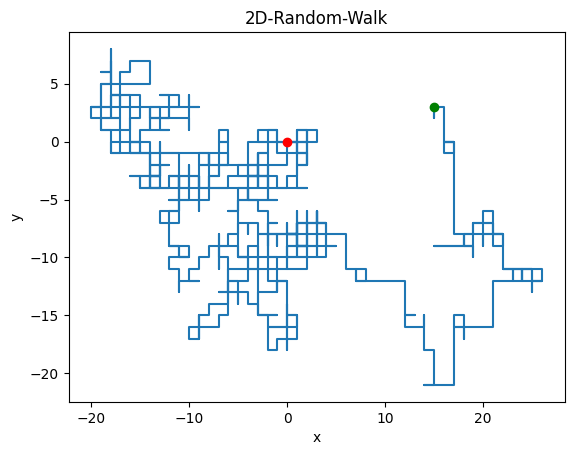

In [14]:
steps = 1000
x, y = random_walk_2d(steps, 42).T

plt.plot(x, y)
plt.plot(x[0], y[0], "ro", label="Start")
plt.plot(x[-1], y[-1], "go", label="Ende")
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D-Random-Walk")
plt.show()

#### c) Rückkehrzeit des Random Walks in 2D

> "A drunk man will find his way home, but a drunk bird may get lost forever." - Shizuo Kakutani

Das nächste Ziel ist es herauszufinden, nach wie vielen Schritten der 2D Random Walk wieder zum Ausgangspunkt zurückkehrt. Dies nennt man die **Rückkehrzeit** (engl. first return time)

Schreibe dazu eine Funktion `first_return_time(max_steps=1000, seed=None)`, die einen Random Walk in 2D durchführt bis er wieder am Ausgangspunkt angekommen ist. `max_steps` soll hierbei als Abbruchkriterium für die maximale Anzahl Schritte dienen. Die Funktion soll die Anzahl Schritte bis zur ersten Rückkehr zum Ursprung zurückgeben. Ansonsten gelten die gleichen Regeln wie in Aufgabe a).

- ["Drunkard's Walk" - Wikipedia](https://de.wikipedia.org/wiki/Drunkard%E2%80%99s_Walk)
- ["Random walks in 2D and 3D are fundamentally different (Markov chains approach)" - Mathemaniac](https://www.youtube.com/watch?v=iH2kATv49rc&t=141s)

Probiere es mit verschiedenen Seeds aus.

In [15]:
def first_return_time(max_steps=1000, seed=None):
    rng = np.random.default_rng(seed)
    possible_steps = ((1, 0), (-1, 0), (0, 1), (0, -1))
    x, y = 0, 0
    steps = 0
    while steps < max_steps:
        steps += 1
        dx, dy = rng.choice(possible_steps)
        x += dx
        y += dy
        if x == 0 and y == 0:
            break

    return steps


first_return_time()

2

#### d) Darstellen der Verteilung der Rückkehrzeit

Ähnlich wie in Aufgabe 2d) sollen nun viele Simulationen berechnet und jeweils die erste Rückkehrzeit bestimmt werden. Also wieder eine Monte-Carlo-Simulation.

- Bestimme die erste Rückkehrzeit mit `first_return_time()` und `max_steps=1000` für 500 Walks mit unterschiedlichen Seeds.
- Stelle die (relative) Häufigkeitsdichte der ersten Rückkehrzeit mit einem Histogramm dar. Verwende dazu die Funktion `plt.hist()` mit der Option `bins="fd"`, damit die Freedman-Diaconis-Regel für die Bestimmung der Anzahl Bins verwendet wird.
- Schreibe die Anzahl Simulationen und Mittelwert und Standardabweichung der Rückkehrzeit in den Titel des Diagramms.

Erhöhe die maximale Anzahl Schritte `max_steps` und beobachte, wie sich die Verteilung verändert.

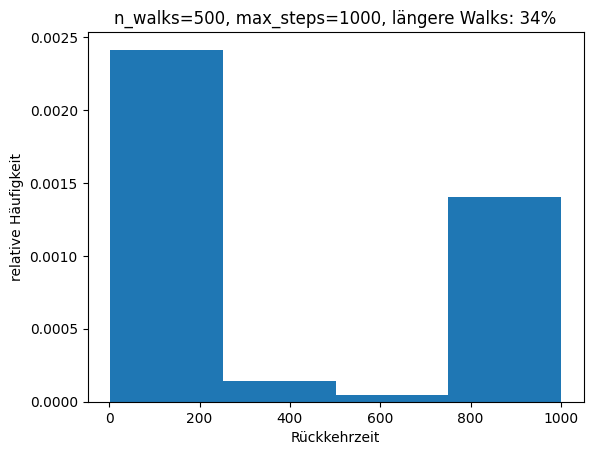

In [16]:
max_steps = 1000
n_walks = 500

return_times = np.array([first_return_time(max_steps) for _ in range(n_walks)])

plt.hist(return_times, bins="fd", density=True)
plt.xlabel("Rückkehrzeit")
plt.ylabel("relative Häufigkeit")
plt.title(
    f"n_walks={n_walks}, max_steps={max_steps}, längere Walks: {np.sum(return_times >= max_steps)/n_walks:.0%}"
)
plt.show()

In [17]:
np.sum(return_times == max_steps) / n_walks

np.float64(0.338)

**Beobachtungen**:
- Die Rückkehrzeit ist meist eher kurz (< 200 Schritte).
- Doch kommen sehr viele sehr sehr lange Rückkehrzeiten (~ 1000 Schritte) vor.
- Es sind ca 1/3 der Walks, die mehr als 1000 Schritte benötigen.
- Erhöht man die maximale Anzahl Schritte, so wird die Verteilung immer breiter und die Wahrscheinlichkeit für sehr lange Rückkehrzeiten nimmt nur leicht ab.